# BÀI 3 - Recommender Systems
## Collaborative Filtering và Content-Based Filtering


## 1. Upload và đọc dữ liệu

Upload ratings.csv và movies.csv

In [1]:
from google.colab import files
import random

print('Hãy chọn đồng thời 2 file: ratings.csv và movies.csv')
uploaded_files = files.upload()

required_files = {'ratings.csv', 'movies.csv'}
uploaded_names = set(uploaded_files.keys())
missing_files = required_files - uploaded_names

if missing_files:
    missing_text = ', '.join(sorted(missing_files))
    raise FileNotFoundError(
        f'Thiếu file: {missing_text}. Hãy chạy lại ô và chọn đủ cả hai file CSV.'
    )

print('Đã upload đủ:', ', '.join(sorted(required_files)))

Hãy chọn đồng thời 2 file: ratings.csv và movies.csv


Saving movies.csv to movies.csv
Saving ratings.csv to ratings.csv
Đã upload đủ: movies.csv, ratings.csv


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ratings_path = 'ratings.csv'
movies_path = 'movies.csv'

ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path)

print('Kích thước ratings:', ratings.shape)
print('Kích thước movies:', movies.shape)
display(ratings.head())
display(movies.head())

Kích thước ratings: (100836, 4)
Kích thước movies: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Phần A - Collaborative Filtering từ đầu

Ta lấy 100 phim có nhiều rating nhất. Trong các rating của 100 phim này, ta tiếp tục lấy 200 user có nhiều rating nhất. Cách làm này tạo ra ma trận nhỏ và tương đối ít ô trống.

In [6]:
number_of_movies = 100
number_of_users = 200

movie_rating_counts = ratings['movieId'].value_counts()
top_movie_ids = movie_rating_counts.head(number_of_movies).index
ratings_of_top_movies = ratings[ratings['movieId'].isin(top_movie_ids)].copy()

user_rating_counts = ratings_of_top_movies['userId'].value_counts()
top_user_ids = user_rating_counts.head(number_of_users).index

ratings_small = ratings_of_top_movies[
    ratings_of_top_movies['userId'].isin(top_user_ids)
].copy()

movie_ids = top_movie_ids.to_numpy()
user_ids = top_user_ids.to_numpy()

print('Số phim:', len(movie_ids))
print('Số user:', len(user_ids))
print('Số rating được giữ lại:', len(ratings_small))

Số phim: 100
Số user: 200
Số rating được giữ lại: 10456


In [7]:
rating_table = ratings_small.pivot(
    index='movieId',
    columns='userId',
    values='rating'
)

rating_table = rating_table.reindex(index=movie_ids, columns=user_ids)

Y = rating_table.fillna(0).to_numpy(dtype=np.float32)
R = rating_table.notna().to_numpy(dtype=np.float32)

density = R.sum() / R.size
print('Shape của Y:', Y.shape)
print('Shape của R:', R.shape)
print('Tỉ lệ ô đã có rating:', round(float(density), 4))
print('Số NaN trong Y:', np.isnan(Y).sum())
print('Giá trị duy nhất trong R:', np.unique(R))

Shape của Y: (100, 200)
Shape của R: (100, 200)
Tỉ lệ ô đã có rating: 0.5228
Số NaN trong Y: 0
Giá trị duy nhất trong R: [0. 1.]


### Hàm cost collaborative filtering

Ký hiệu:

- `X[i]`: vector đặc trưng ẩn của phim i.
- `W[j]` và `b[j]`: tham số của user j.
- Dự đoán tại ô `(i, j)` là `X[i] dot W[j] + b[j]`.
- Nhân sai số với `R` để chỉ tính các ô đã có rating.
- Regularization được áp dụng cho `X` và `W`, giống công thức trong bài giảng.

In [8]:
def cofi_cost_func(X, W, b, Y, R, lambda_):
    predictions = tf.matmul(X, tf.transpose(W)) + b
    errors = (predictions - Y) * R

    data_cost = 0.5 * tf.reduce_sum(errors ** 2)
    regularization_cost = 0.5 * lambda_ * (
        tf.reduce_sum(X ** 2) + tf.reduce_sum(W ** 2)
    )

    total_cost = data_cost + regularization_cost
    return total_cost

## Phần B - Huấn luyện bằng TensorFlow

### Mean normalization

Với mỗi phim, ta lấy trung bình trên các rating thật. Sau đó ta trừ trung bình này khỏi các rating đã biết. Ô chưa có rating vẫn giữ bằng 0 nhờ nhân với `R`.

In [9]:
number_of_ratings_per_movie = np.sum(R, axis=1)
Y_mean = np.sum(Y, axis=1) / number_of_ratings_per_movie

# reshape(-1, 1) đổi Y_mean thành một cột để trừ cho từng cột user.
Y_mean_column = Y_mean.reshape(-1, 1)
Y_normalized = (Y - Y_mean_column) * R

print('5 rating trung bình đầu tiên:', Y_mean[:5])
print('Giá trị nhỏ nhất/lớn nhất sau chuẩn hóa:',
      Y_normalized.min(), Y_normalized.max())

5 rating trung bình đầu tiên: [4.1350574 4.423841  4.313291  4.1597223 4.1962028]
Giá trị nhỏ nhất/lớn nhất sau chuẩn hóa: -3.7868218 2.2272727


Ta thêm một user mới vào cuối ma trận. User này chưa rating phim nào, vì vậy toàn bộ cột mới trong `Y` và `R` đều bằng 0.

In [10]:
new_user_ratings = np.zeros((number_of_movies, 1), dtype=np.float32)
new_user_R = np.zeros((number_of_movies, 1), dtype=np.float32)

Y_train_cf = np.concatenate([Y_normalized, new_user_ratings], axis=1)
R_train_cf = np.concatenate([R, new_user_R], axis=1)

print('Shape sau khi thêm user mới:', Y_train_cf.shape)
print('Số rating của user mới:', int(R_train_cf[:, -1].sum()))

Shape sau khi thêm user mới: (100, 201)
Số rating của user mới: 0


### Custom training loop với `tf.GradientTape`

Đây là vòng lặp huấn luyện viết trực tiếp. `GradientTape` ghi lại phép tính cost, tính gradient rồi Adam cập nhật `X`, `W`, `b`.

In [11]:
number_of_features = 20
total_number_of_users = Y_train_cf.shape[1]
lambda_ = 1.0
learning_rate = 0.1
number_of_iterations = 300

X = tf.Variable(
    tf.random.normal((number_of_movies, number_of_features), stddev=0.1)
)
W = tf.Variable(
    tf.random.normal((total_number_of_users, number_of_features), stddev=0.1)
)
b = tf.Variable(tf.zeros((1, total_number_of_users)))

# User mới không có dữ liệu. Khởi tạo tham số của user này bằng 0.
W[-1].assign(tf.zeros(number_of_features))
b[0, -1].assign(0.0)

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
cost_history = []

Y_tensor = tf.constant(Y_train_cf, dtype=tf.float32)
R_tensor = tf.constant(R_train_cf, dtype=tf.float32)

variables = [X, W, b]

for iteration in range(number_of_iterations):
    with tf.GradientTape() as tape:
        cost = cofi_cost_func(X, W, b, Y_tensor, R_tensor, lambda_)

    # Tính mức cần thay đổi của từng biến X, W và b.
    gradients = tape.gradient(cost, variables)

    # Ghép mỗi gradient với đúng biến rồi cập nhật biến đó.
    gradient_variable_pairs = zip(gradients, variables)
    optimizer.apply_gradients(gradient_variable_pairs)
    cost_history.append(float(cost))

    if iteration % 50 == 0:
        print('Lần lặp:', iteration, '- Cost:', round(float(cost), 2))

Lần lặp: 0 - Cost: 3857.63
Lần lặp: 50 - Cost: 1019.63
Lần lặp: 100 - Cost: 994.29
Lần lặp: 150 - Cost: 987.89
Lần lặp: 200 - Cost: 986.38
Lần lặp: 250 - Cost: 983.12


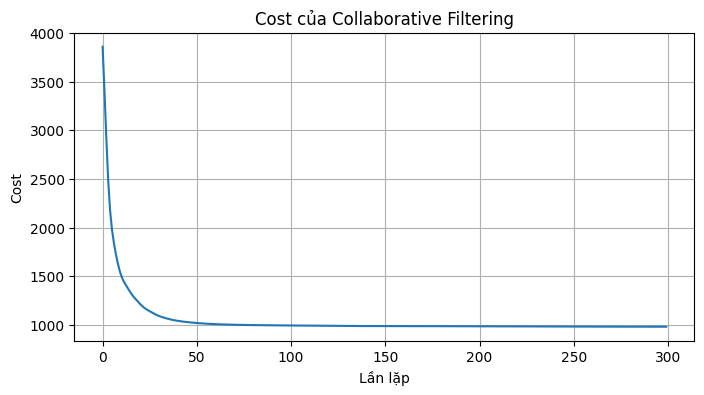

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.xlabel('Lần lặp')
plt.ylabel('Cost')
plt.title('Cost của Collaborative Filtering')
plt.grid()
plt.show()

In [13]:
predictions_normalized = tf.matmul(X, tf.transpose(W)) + b
predictions_cf = predictions_normalized.numpy() + Y_mean_column
predictions_cf = np.clip(predictions_cf, 0.5, 5.0)

# Cột cuối là user mới. Các cột trước đó là 200 user ban đầu.
predictions_of_old_users = predictions_cf[:, 0:number_of_users]
known_errors = (predictions_of_old_users - Y) * R
cf_rmse = np.sqrt(np.sum(known_errors ** 2) / np.sum(R))
print('RMSE trên các rating dùng để train:', round(float(cf_rmse), 4))
print('Dự đoán chuẩn hóa lớn nhất của user mới:',
      round(float(np.abs(predictions_normalized[:, -1]).max()), 6))

RMSE trên các rating dùng để train: 0.32
Dự đoán chuẩn hóa lớn nhất của user mới: 0.0


In [14]:
movie_names = movies.set_index('movieId')['title']
new_user_predictions = predictions_cf[:, -1]

cold_start_results = pd.DataFrame({
    'movieId': movie_ids,
    'title': movie_names.loc[movie_ids].to_numpy(),
    'predicted_rating': new_user_predictions
})

cold_start_results = cold_start_results.sort_values(
    by='predicted_rating',
    ascending=False
)
cold_start_recommendations = cold_start_results.head(10)

print('Top 10 cho user mới chưa rating phim nào:')
display(cold_start_recommendations.round(3))

Top 10 cho user mới chưa rating phim nào:


,movieId,title,predicted_rating
1,318,"Shawshank Redemption, The (1994)",4.424
21,858,"Godfather, The (1972)",4.332
2,296,Pulp Fiction (1994),4.313
12,1196,Star Wars: Episode V - The Empire Strikes Back...,4.293
9,527,Schindler's List (1993),4.293
10,2959,Fight Club (1999),4.287
52,1197,"Princess Bride, The (1987)",4.258
5,260,Star Wars: Episode IV - A New Hope (1977),4.257
18,1198,Raiders of the Lost Ark (Indiana Jones and the...,4.228
14,50,"Usual Suspects, The (1995)",4.227


### Vì sao mean normalization giúp cold-start?

User mới không có rating nên không có sai số dữ liệu để học `W` và `b`. Với khởi tạo bằng 0, dự đoán trên dữ liệu đã chuẩn hóa của user này vẫn bằng 0.

Nhưng 0 ở đây mang nghĩa **không lệch khỏi mức trung bình của phim**. Khi cộng `Y_mean` trở lại, dự đoán cuối cùng chính là rating trung bình của từng phim, thay vì tất cả phim đều nhận điểm 0. Đây là một baseline hợp lý khi ta chưa biết sở thích của user. Các gợi ý lúc này chưa được cá nhân hóa.

### Lưu gợi ý Collaborative Filtering cho một user cũ

Để so sánh công bằng về mặt danh sách, Phần C sẽ dùng cùng user này và loại bỏ những phim user đã xem.

In [15]:
# Chọn user ở giữa danh sách để vẫn còn đủ phim chưa xem.
comparison_user_position = number_of_users // 2
comparison_user_id = user_ids[comparison_user_position]
has_watched = R[:, comparison_user_position] == 1

cf_results = pd.DataFrame({
    'movieId': movie_ids,
    'title': movie_names.loc[movie_ids].to_numpy(),
    'cf_score': predictions_cf[:, comparison_user_position],
    'has_watched': has_watched
})

cf_unwatched = cf_results[cf_results['has_watched'] == False]
cf_unwatched = cf_unwatched.sort_values(by='cf_score', ascending=False)
cf_recommendations = cf_unwatched.head(10)

print('User được dùng để so sánh:', comparison_user_id)
display(cf_recommendations.round(3))

User được dùng để so sánh: 334


,movieId,title,cf_score,has_watched
52,1197,"Princess Bride, The (1987)",4.440,False
78,1682,"Truman Show, The (1998)",4.189,False
87,1206,"Clockwork Orange, A (1971)",4.178,False
68,6874,Kill Bill: Vol. 1 (2003),3.985,False
47,1036,Die Hard (1988),3.970,False
13,2858,American Beauty (1999),3.959,False
49,165,Die Hard: With a Vengeance (1995),3.949,False
27,588,Aladdin (1992),3.919,False
14,50,"Usual Suspects, The (1995)",3.912,False
30,380,True Lies (1994),3.907,False


## Phần C - Content-Based Filtering

Ta tạo dữ liệu cho hai mạng riêng:

- **User network:** nhận rating trung bình, số rating và điểm yêu thích từng genre của user.
- **Item network:** nhận năm phát hành, rating trung bình, số rating và các genre của phim.

Các thống kê chỉ được tính từ tập train. Scaler cũng chỉ `fit` trên tập train để tránh data leakage.

Một số lệnh Pandas được dùng ở phần này:

- `groupby(...).mean()`: gom các dòng cùng user/phim rồi tính trung bình.
- `reindex(...)`: sắp bảng theo đúng thứ tự ID đang dùng.
- `merge(...)`: ghép hai bảng dựa trên cột `movieId`.
- `.loc[danh_sách_id]`: lấy nhiều dòng theo thứ tự của danh sách ID.

In [16]:
train_ratings, test_ratings = train_test_split(
    ratings_small,
    test_size=0.2,
    random_state=SEED
)
train_ratings = train_ratings.copy()
test_ratings = test_ratings.copy()

# Chỉ giữ thông tin của 100 phim đã chọn.
is_selected_movie = movies['movieId'].isin(movie_ids)
movies_small = movies[is_selected_movie].copy()

# Biến cột genres thành các cột 0/1, ví dụ Action, Comedy, Drama.
genre_table = movies_small['genres'].str.get_dummies(sep='|')
genre_table = genre_table.astype(float)
genre_names = genre_table.columns.tolist()

movies_small = pd.concat(
    [movies_small.reset_index(drop=True), genre_table.reset_index(drop=True)],
    axis=1
)
movies_small['year'] = pd.to_numeric(
    movies_small['title'].str.extract(r'\((\d{4})\)$')[0],
    errors='coerce'
)

print('Số dòng train:', len(train_ratings))
print('Số dòng test:', len(test_ratings))
print('Các genre:', genre_names)

Số dòng train: 8364
Số dòng test: 2092
Các genre: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Drama', 'Fantasy', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [17]:
global_train_mean = train_ratings['rating'].mean()

# Tính riêng rating trung bình và số rating của từng user.
user_mean = train_ratings.groupby('userId')['rating'].mean()
user_count = train_ratings.groupby('userId')['rating'].count()

user_features = pd.DataFrame(index=user_ids)
user_features['user_mean'] = user_mean.reindex(user_ids)
user_features['user_count'] = user_count.reindex(user_ids)
user_features['user_mean'] = user_features['user_mean'].fillna(global_train_mean)
user_features['user_count'] = user_features['user_count'].fillna(0)

# Ghép genre của phim vào từng dòng rating.
genre_columns = ['movieId'] + genre_names
movie_genres = movies_small[genre_columns]
train_with_genres = train_ratings.merge(movie_genres, on='movieId')

for genre in genre_names:
    # Ví dụ với Comedy: chỉ lấy rating của các phim Comedy.
    is_this_genre = train_with_genres[genre] == 1
    rows_of_genre = train_with_genres[is_this_genre]
    preference = rows_of_genre.groupby('userId')['rating'].mean()
    column_name = 'preference_' + genre
    user_features[column_name] = preference.reindex(user_ids)
    user_features[column_name] = user_features[column_name].fillna(global_train_mean)

user_feature_names = user_features.columns.tolist()
display(user_features.head())

,user_mean,user_count,preference_Action,preference_Adventure,preference_Animation,preference_Children,preference_Comedy,preference_Crime,preference_Drama,preference_Fantasy,preference_Horror,preference_IMAX,preference_Musical,preference_Mystery,preference_Romance,preference_Sci-Fi,preference_Thriller,preference_War,preference_Western
414,4.294118,85,4.230769,4.125000,3.928571,4.050000,4.120000,4.395833,4.516667,4.125000,4.25,4.100000,3.750000,4.555556,4.115385,4.500000,4.344828,4.750,4.000000
68,3.621622,74,3.800000,4.051724,4.200000,3.357143,3.428571,3.285714,3.400000,3.958333,3.00,4.166667,4.500000,3.785714,3.928571,3.650000,3.553571,3.500,4.000000
480,3.883117,77,3.797297,3.640625,3.285714,3.590909,3.589286,3.805556,4.346154,3.550000,4.00,3.666667,3.666667,3.900000,3.727273,4.088235,3.727273,4.875,5.000000
274,3.852564,78,3.684211,3.600000,3.666667,3.666667,3.900000,4.100000,4.160714,3.600000,4.00,3.875000,3.625000,4.111111,3.909091,3.818182,3.880000,4.250,4.000000
599,3.626667,75,3.605263,3.396552,3.000000,3.125000,3.400000,3.850000,3.653846,3.291667,4.25,3.083333,3.125000,3.785714,3.433333,3.868421,3.807692,3.500,3.850849


In [18]:
# Tính riêng rating trung bình và số rating của từng phim.
movie_mean = train_ratings.groupby('movieId')['rating'].mean()
movie_count = train_ratings.groupby('movieId')['rating'].count()

item_features = movies_small.set_index('movieId').copy()
item_features = item_features.reindex(movie_ids)
item_features['movie_mean'] = movie_mean.reindex(movie_ids)
item_features['movie_count'] = movie_count.reindex(movie_ids)

median_year = item_features['year'].median()
item_features['year'] = item_features['year'].fillna(median_year)
item_features['movie_mean'] = item_features['movie_mean'].fillna(global_train_mean)
item_features['movie_count'] = item_features['movie_count'].fillna(0)

item_feature_names = ['year', 'movie_mean', 'movie_count'] + genre_names
item_features = item_features[item_feature_names]
display(item_features.head())

,year,movie_mean,movie_count,Action,Adventure,Animation,Children,Comedy,Crime,Drama,Fantasy,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,,,
356,1994,4.137255,153,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
318,1994,4.478448,116,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
296,1994,4.368217,129,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
593,1991,4.115741,108,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2571,1999,4.236641,131,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [19]:
# Mỗi dòng rating cần một vector user và một vector phim tương ứng.
train_user_ids = train_ratings['userId']
train_movie_ids = train_ratings['movieId']
X_user_train = user_features.loc[train_user_ids].to_numpy()
X_item_train = item_features.loc[train_movie_ids].to_numpy()
y_train = train_ratings['rating'].to_numpy().reshape(-1, 1)

test_user_ids = test_ratings['userId']
test_movie_ids = test_ratings['movieId']
X_user_test = user_features.loc[test_user_ids].to_numpy()
X_item_test = item_features.loc[test_movie_ids].to_numpy()
y_test = test_ratings['rating'].to_numpy().reshape(-1, 1)

user_scaler = StandardScaler()
item_scaler = StandardScaler()
rating_scaler = MinMaxScaler(feature_range=(-1, 1))

X_user_train_scaled = user_scaler.fit_transform(X_user_train)
X_item_train_scaled = item_scaler.fit_transform(X_item_train)
y_train_scaled = rating_scaler.fit_transform(y_train)

X_user_test_scaled = user_scaler.transform(X_user_test)
X_item_test_scaled = item_scaler.transform(X_item_test)

print('User input shape:', X_user_train_scaled.shape)
print('Item input shape:', X_item_train_scaled.shape)
print('Target shape:', y_train_scaled.shape)
user_data_has_nan = np.isnan(X_user_train_scaled).any()
item_data_has_nan = np.isnan(X_item_train_scaled).any()
training_data_has_nan = user_data_has_nan or item_data_has_nan
print('Có NaN trong dữ liệu train:', training_data_has_nan)

User input shape: (8364, 19)
Item input shape: (8364, 20)
Target shape: (8364, 1)
Có NaN trong dữ liệu train: False


### Hai neural network và dot product

Hai mạng có kiến trúc giống nhau nhưng tham số riêng. Mỗi mạng biến đầu vào thành một vector 32 chiều. Sau khi chuẩn hóa độ dài hai vector, dot product cho ra điểm dự đoán trong khoảng gần `[-1, 1]`, cùng khoảng với target đã scale.

In [20]:
number_of_user_features = X_user_train_scaled.shape[1]
number_of_item_features = X_item_train_scaled.shape[1]
embedding_size = 32

user_network = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(number_of_user_features,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(embedding_size)
], name='user_network')

item_network = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(number_of_item_features,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(embedding_size)
], name='item_network')

user_input = tf.keras.layers.Input(shape=(number_of_user_features,))
item_input = tf.keras.layers.Input(shape=(number_of_item_features,))

user_vector = user_network(user_input)
item_vector = item_network(item_input)

user_vector = tf.keras.layers.UnitNormalization(axis=1)(user_vector)
item_vector = tf.keras.layers.UnitNormalization(axis=1)(item_vector)
prediction = tf.keras.layers.Dot(axes=1)([user_vector, item_vector])

content_model = tf.keras.Model(
    inputs=[user_input, item_input],
    outputs=prediction
)

content_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error'
)
content_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_network        │ (None, 32)        │     12,896 │ input_layer_2[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_network        │ (None, 32)        │     13,024 │ input_layer_3[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unit_normalization  │ (None, 32)        │          0 │ user_network[0][… │
│ (UnitNormalization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unit_normalization… │ (None, 32)        │          0 │ item_network[0][… │
│ (UnitNormalization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ unit_normalizati… │
│                     │                   │            │ unit_normalizati… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,920 (101.25 KB)

 Trainable params: 25,920 (101.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = content_model.fit(
    [X_user_train_scaled, X_item_train_scaled],
    y_train_scaled,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1443 - val_loss: 0.1178
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1154 - val_loss: 0.1085
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1060 - val_loss: 0.1044
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1002 - val_loss: 0.1022
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0957 - val_loss: 0.1005
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0921 - val_loss: 0.0992
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0894 - val_loss: 0.0978
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0871 - val_loss: 0.0968
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0851 - val_loss: 0.0963
Epoch 10/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0836 - val_loss: 0.0959
Epoch 11/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0822 - val_loss: 0.0959
Epoch 12/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0811 - val_l

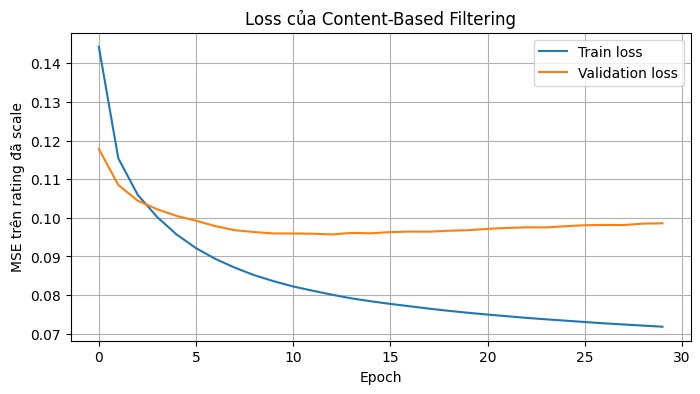

Content-based test RMSE: 0.7492


In [22]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE trên rating đã scale')
plt.title('Loss của Content-Based Filtering')
plt.legend()
plt.grid()
plt.show()

test_predictions_scaled = content_model.predict(
    [X_user_test_scaled, X_item_test_scaled],
    verbose=0
)
test_predictions = rating_scaler.inverse_transform(test_predictions_scaled)
test_predictions = np.clip(test_predictions, 0.5, 5.0)
content_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
print('Content-based test RMSE:', round(float(content_rmse), 4))

### Tạo gợi ý Content-Based cho cùng user

Ta lặp lại vector đặc trưng của user cho 100 phim, dự đoán tất cả điểm, rồi loại các phim user đã xem.

In [ ]:
one_user_features = user_features.loc[[comparison_user_id]].to_numpy()
one_user_features_scaled = user_scaler.transform(one_user_features)
all_user_inputs = np.repeat(one_user_features_scaled, number_of_movies, axis=0)

all_item_inputs = item_features.loc[movie_ids].to_numpy()
all_item_inputs_scaled = item_scaler.transform(all_item_inputs)

all_scores_scaled = content_model.predict(
    [all_user_inputs, all_item_inputs_scaled],
    verbose=0
)
all_scores_content = rating_scaler.inverse_transform(all_scores_scaled).ravel()
all_scores_content = np.clip(all_scores_content, 0.5, 5.0)

content_results = pd.DataFrame({
    'movieId': movie_ids,
    'title': movie_names.loc[movie_ids].to_numpy(),
    'content_score': all_scores_content,
    'has_watched': has_watched
})

content_unwatched = content_results[content_results['has_watched'] == False]
content_unwatched = content_unwatched.sort_values(
    by='content_score',
    ascending=False
)
content_recommendations = content_unwatched.head(10)

display(content_recommendations.round(3))

## So sánh hai danh sách gợi ý

Bảng dưới đặt hai top 10 cạnh nhau và tính số phim xuất hiện trong cả hai danh sách. Hai mô hình không nhất thiết cho kết quả giống nhau:

- Collaborative filtering học các yếu tố ẩn từ hành vi rating chung của nhiều user.
- Content-based dựa vào các đặc trưng đã tạo như genre, năm và hồ sơ genre của user.
- Content-based có thể giải thích theo đặc trưng rõ hơn, nhưng bị giới hạn bởi chất lượng đặc trưng.
- Collaborative filtering thường tìm được quan hệ tinh tế hơn, nhưng gặp khó với user/item hoàn toàn mới.

In [ ]:
comparison_table = pd.DataFrame({
    'CF title': cf_recommendations['title'],
    'CF score': cf_recommendations['cf_score'],
    'Content title': content_recommendations['title'],
    'Content score': content_recommendations['content_score']
})

cf_movie_ids = set(cf_recommendations['movieId'])
content_movie_ids = set(content_recommendations['movieId'])
common_movie_ids = cf_movie_ids.intersection(content_movie_ids)

print('User:', comparison_user_id)
print('Số phim trùng nhau trong hai top 10:', len(common_movie_ids))
display(comparison_table.round(3))

## Kết luận

- Ma trận `Y` lưu rating; `R` cho biết ô nào thực sự có rating.
- Collaborative filtering học đồng thời vector phim và vector user bằng `tf.GradientTape`.
- Mean normalization biến dự đoán 0 của user cold-start thành rating trung bình hợp lý sau khi cộng mean trở lại.
- Content-based dùng hai neural network để đưa user và item về cùng không gian vector rồi lấy dot product.
- So sánh top 10 mang tính minh họa. RMSE collaborative ở trên là train RMSE, còn RMSE content-based là test RMSE, nên không dùng hai số đó để kết luận mô hình nào tốt hơn. Muốn benchmark chặt chẽ, cả hai mô hình phải dùng cùng một cách chia train/test.